# Notebook to find Hashtag Doublets and Demultiplex multinucleated data using `HTODemux`

**Created by :** Srivalli Kolla

**Created on :** 01 April, 2025

**Modified on :** 09 April, 2025

**University of Würzburg**

Env : scanpy (Python 3.12.2)

# Importing Packages

In [5]:
import scanpy as sc
import pandas as pd
import datetime
import os
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib import rcParams

In [6]:
sc.settings.verbosity = 3
sc.logging.print_versions()

plt.rcParams['figure.dpi'] = 300  
plt.rcParams['savefig.dpi'] = 300
plt.vlines

timestamp = datetime.datetime.now().strftime("%d_%m_%y")

-----
anndata     0.11.3
scanpy      1.10.4
-----
Cython                      3.0.12
PIL                         11.1.0
anyio                       NA
arrow                       1.3.0
asttokens                   NA
attr                        25.1.0
attrs                       25.1.0
babel                       2.17.0
certifi                     2025.01.31
charset_normalizer          3.4.1
colorama                    0.4.6
comm                        0.2.2
cycler                      0.12.1
cython                      3.0.12
cython_runtime              NA
dateutil                    2.9.0.post0
debugpy                     1.8.12
decorator                   5.2.1
defusedxml                  0.7.1
executing                   2.1.0
fastjsonschema              NA
fqdn                        NA
h5py                        3.13.0
idna                        3.10
igraph                      0.11.8
ipykernel                   6.29.5
ipywidgets                  8.1.5
isoduration               

/home/gruengroup/srivalli/miniconda3/envs/scanpy/lib/python3.13/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


# Importing files

In [7]:
raw_adata = sc.read_h5ad('./data/demultiplexed_HTODemux_raw.h5ad')
raw_adata

AnnData object with n_obs × n_vars = 41918 × 32285
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'ident'
    uns: 'X_name'
    layers: 'logcounts'

In [8]:
raw_adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,nCount_HTO,nFeature_HTO,HTO_maxID,HTO_secondID,HTO_margin,HTO_classification,HTO_classification.global,hash.ID,ident
AAACCAAAGCCAGTGT-1,SeuratProject,14083.0,3886,1960.0,8,TotalSeqB4,TotalSeqB9,0.575627,TotalSeqB4_TotalSeqB9,Doublet,Doublet,Doublet
AAACCAAAGGCGTCCA-1,SeuratProject,7966.0,2771,1928.0,8,TotalSeqB4,TotalSeqB9,0.377318,TotalSeqB4,Singlet,TotalSeqB4,Singlet
AAACCAAAGGTTAGCC-1,SeuratProject,4451.0,2271,1861.0,8,TotalSeqB3,TotalSeqB6,0.094148,Negative,Negative,Negative,Negative
AAACCAAAGGTTAGTT-1,SeuratProject,13944.0,4187,1658.0,8,TotalSeqB5,TotalSeqB6,0.270208,Negative,Negative,Negative,Negative
AAACCAAAGTACCACA-1,SeuratProject,11424.0,3923,1655.0,8,TotalSeqB7,TotalSeqB9,0.107273,Negative,Negative,Negative,Negative
...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGTTGAGCCTATCT-1,SeuratProject,8738.0,3805,2570.0,8,TotalSeqB7,TotalSeqB8,0.052030,TotalSeqB7_TotalSeqB8,Doublet,Doublet,Doublet
TGTGTTGAGCTAACCA-1,SeuratProject,16178.0,4236,1872.0,8,TotalSeqB4,TotalSeqB8,0.949875,TotalSeqB4,Singlet,TotalSeqB4,Singlet
TGTGTTGAGGAGGACC-1,SeuratProject,4898.0,2244,911.0,8,TotalSeqB4,TotalSeqB8,0.164266,Negative,Negative,Negative,Negative
TGTGTTGAGTACGCAC-1,SeuratProject,5921.0,2736,2001.0,8,TotalSeqB4,TotalSeqB8,0.096781,TotalSeqB4,Singlet,TotalSeqB4,Singlet


In [9]:
raw_adata.var

""
Xkr4
Gm1992
Gm19938
Gm37381
Rp1
...
AC124606.1
AC133095.2
AC133095.1
AC234645.1


In [10]:
raw_adata.obs['HTO_classification'].unique()

['TotalSeqB4_TotalSeqB9', 'TotalSeqB4', 'Negative', 'TotalSeqB6', 'TotalSeqB3_TotalSeqB5', ..., 'TotalSeqB5_TotalSeqB6', 'TotalSeqB1_TotalSeqB5', 'TotalSeqB4_TotalSeqB7', 'TotalSeqB5_TotalSeqB9', 'TotalSeqB3_TotalSeqB4']
Length: 37
Categories (37, object): ['Negative', 'TotalSeqB1', 'TotalSeqB1_TotalSeqB3', 'TotalSeqB1_TotalSeqB4', ..., 'TotalSeqB7_TotalSeqB9', 'TotalSeqB8', 'TotalSeqB8_TotalSeqB9', 'TotalSeqB9']

# Adding Metadata

In [11]:
metadata = pd.read_csv('./Github/Nuclear_hashing_2025/data/Nuclei_hashing_metadata.csv', sep = ';')
metadata

,Sample_given,Sample-ID,Mouse-ID,Sex,Group,Ref hashtag,Nuclei Purification Method after Hashing,assigned_hashtag
0,20241028_AC_Pkp2-MCMV_Mouse_Multiplex_Heart_10,10,24-2455,Male,MCMV,TotalSeqB1,Standard,MCMV_ST_Hash1
1,20241028_AC_Pkp2-MCMV_Mouse_Multiplex_Heart_11,11,26-2457,Male,MCMV,TotalSeqB9,Standard,MCMV_ST_Hash9
2,20241028_AC_Pkp2-MCMV_Mouse_Multiplex_Heart_12,12,25-2456,Male,MCMV,TotalSeqB3,Magnetic Beads,MCMV_MB_Hash3
3,20241028_AC_Pkp2-MCMV_Mouse_Multiplex_Heart_13,13,#5_DZHI_12.07.2023,Male,MCMV,TotalSeqB4,Magnetic Beads,MCMV_MB_Hash4
4,20241028_AC_Pkp2-MCMV_Mouse_Multiplex_Heart_14,14,9_4893,Female,noninf,TotalSeqB5,Magnetic Beads,Noninf_MB_Hash5
5,20241028_AC_Pkp2-MCMV_Mouse_Multiplex_Heart_15,15,2_1219,Female,noninf,TotalSeqB6,Standard,Noninf_ST_Hash6
6,20241028_AC_Pkp2-MCMV_Mouse_Multiplex_Heart_16,16,99_0939,Female,noninf,TotalSeqB7,Magnetic Beads,Noninf_MB_Hash7
7,20241028_AC_Pkp2-MCMV_Mouse_Multiplex_Heart_17,17,20_2418,Female,noninf,TotalSeqB8,Standard,Noninf_ST_Hash8


In [12]:
metadata = metadata.set_index('Ref hashtag')
metadata

,Sample_given,Sample-ID,Mouse-ID,Sex,Group,Nuclei Purification Method after Hashing,assigned_hashtag
Ref hashtag,,,,,,,
TotalSeqB1,20241028_AC_Pkp2-MCMV_Mouse_Multiplex_Heart_10,10,24-2455,Male,MCMV,Standard,MCMV_ST_Hash1
TotalSeqB9,20241028_AC_Pkp2-MCMV_Mouse_Multiplex_Heart_11,11,26-2457,Male,MCMV,Standard,MCMV_ST_Hash9
TotalSeqB3,20241028_AC_Pkp2-MCMV_Mouse_Multiplex_Heart_12,12,25-2456,Male,MCMV,Magnetic Beads,MCMV_MB_Hash3
TotalSeqB4,20241028_AC_Pkp2-MCMV_Mouse_Multiplex_Heart_13,13,#5_DZHI_12.07.2023,Male,MCMV,Magnetic Beads,MCMV_MB_Hash4
TotalSeqB5,20241028_AC_Pkp2-MCMV_Mouse_Multiplex_Heart_14,14,9_4893,Female,noninf,Magnetic Beads,Noninf_MB_Hash5
TotalSeqB6,20241028_AC_Pkp2-MCMV_Mouse_Multiplex_Heart_15,15,2_1219,Female,noninf,Standard,Noninf_ST_Hash6
TotalSeqB7,20241028_AC_Pkp2-MCMV_Mouse_Multiplex_Heart_16,16,99_0939,Female,noninf,Magnetic Beads,Noninf_MB_Hash7
TotalSeqB8,20241028_AC_Pkp2-MCMV_Mouse_Multiplex_Heart_17,17,20_2418,Female,noninf,Standard,Noninf_ST_Hash8


In [13]:
raw_adata.obs = raw_adata.obs.join(metadata, on="HTO_classification", how="left")

raw_adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,nCount_HTO,nFeature_HTO,HTO_maxID,HTO_secondID,HTO_margin,HTO_classification,HTO_classification.global,hash.ID,ident,Sample_given,Sample-ID,Mouse-ID,Sex,Group,Nuclei Purification Method after Hashing,assigned_hashtag
AAACCAAAGCCAGTGT-1,SeuratProject,14083.0,3886,1960.0,8,TotalSeqB4,TotalSeqB9,0.575627,TotalSeqB4_TotalSeqB9,Doublet,Doublet,Doublet,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAACCAAAGGCGTCCA-1,SeuratProject,7966.0,2771,1928.0,8,TotalSeqB4,TotalSeqB9,0.377318,TotalSeqB4,Singlet,TotalSeqB4,Singlet,20241028_AC_Pkp2-MCMV_Mouse_Multiplex_Heart_13,13.0,#5_DZHI_12.07.2023,Male,MCMV,Magnetic Beads,MCMV_MB_Hash4
AAACCAAAGGTTAGCC-1,SeuratProject,4451.0,2271,1861.0,8,TotalSeqB3,TotalSeqB6,0.094148,Negative,Negative,Negative,Negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAACCAAAGGTTAGTT-1,SeuratProject,13944.0,4187,1658.0,8,TotalSeqB5,TotalSeqB6,0.270208,Negative,Negative,Negative,Negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAACCAAAGTACCACA-1,SeuratProject,11424.0,3923,1655.0,8,TotalSeqB7,TotalSeqB9,0.107273,Negative,Negative,Negative,Negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGTTGAGCCTATCT-1,SeuratProject,8738.0,3805,2570.0,8,TotalSeqB7,TotalSeqB8,0.052030,TotalSeqB7_TotalSeqB8,Doublet,Doublet,Doublet,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TGTGTTGAGCTAACCA-1,SeuratProject,16178.0,4236,1872.0,8,TotalSeqB4,TotalSeqB8,0.949875,TotalSeqB4,Singlet,TotalSeqB4,Singlet,20241028_AC_Pkp2-MCMV_Mouse_Multiplex_Heart_13,13.0,#5_DZHI_12.07.2023,Male,MCMV,Magnetic Beads,MCMV_MB_Hash4
TGTGTTGAGGAGGACC-1,SeuratProject,4898.0,2244,911.0,8,TotalSeqB4,TotalSeqB8,0.164266,Negative,Negative,Negative,Negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TGTGTTGAGTACGCAC-1,SeuratProject,5921.0,2736,2001.0,8,TotalSeqB4,TotalSeqB8,0.096781,TotalSeqB4,Singlet,TotalSeqB4,Singlet,20241028_AC_Pkp2-MCMV_Mouse_Multiplex_Heart_13,13.0,#5_DZHI_12.07.2023,Male,MCMV,Magnetic Beads,MCMV_MB_Hash4


# QC check

## Mt and Ribo Genes

In [14]:
raw_adata.var['mt'] = raw_adata.var_names.str.startswith('mt-') 
raw_adata.var['ribo'] = raw_adata.var_names.str.startswith(("Rps","Rpl"))
raw_adata.var

,mt,ribo
Xkr4,False,False
Gm1992,False,False
Gm19938,False,False
Gm37381,False,False
Rp1,False,False
...,...,...
AC124606.1,False,False
AC133095.2,False,False
AC133095.1,False,False
AC234645.1,False,False


In [15]:
ribo_counts = raw_adata.var['ribo'].value_counts()

mt_counts = raw_adata.var['mt'].value_counts()

print("Counts of Ribosomal (ribo) Genes:")
print("False:", ribo_counts.get(False, 0))
print("True:", ribo_counts.get(True, 0))
print("\nCounts of Mitochondrial (mt) Genes:")
print("False:", mt_counts.get(False, 0))
print("True:", mt_counts.get(True, 0))

Counts of Ribosomal (ribo) Genes:
False: 32184
True: 101

Counts of Mitochondrial (mt) Genes:
False: 32272
True: 13


### Calculating QC metrics per cell

In [16]:
sc.pp.calculate_qc_metrics(raw_adata, qc_vars = ['mt','ribo'], percent_top = None, log1p = False, inplace = True)
raw_adata

AnnData object with n_obs × n_vars = 41918 × 32285
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'ident', 'Sample_given', 'Sample-ID', 'Mouse-ID', 'Sex', 'Group', 'Nuclei Purification Method after Hashing', 'assigned_hashtag', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'X_name'
    layers: 'logcounts'

### Visualization of qc metrics

Text(0.5, 1.0, 'Mt and Ribo percentages - Before filtering')

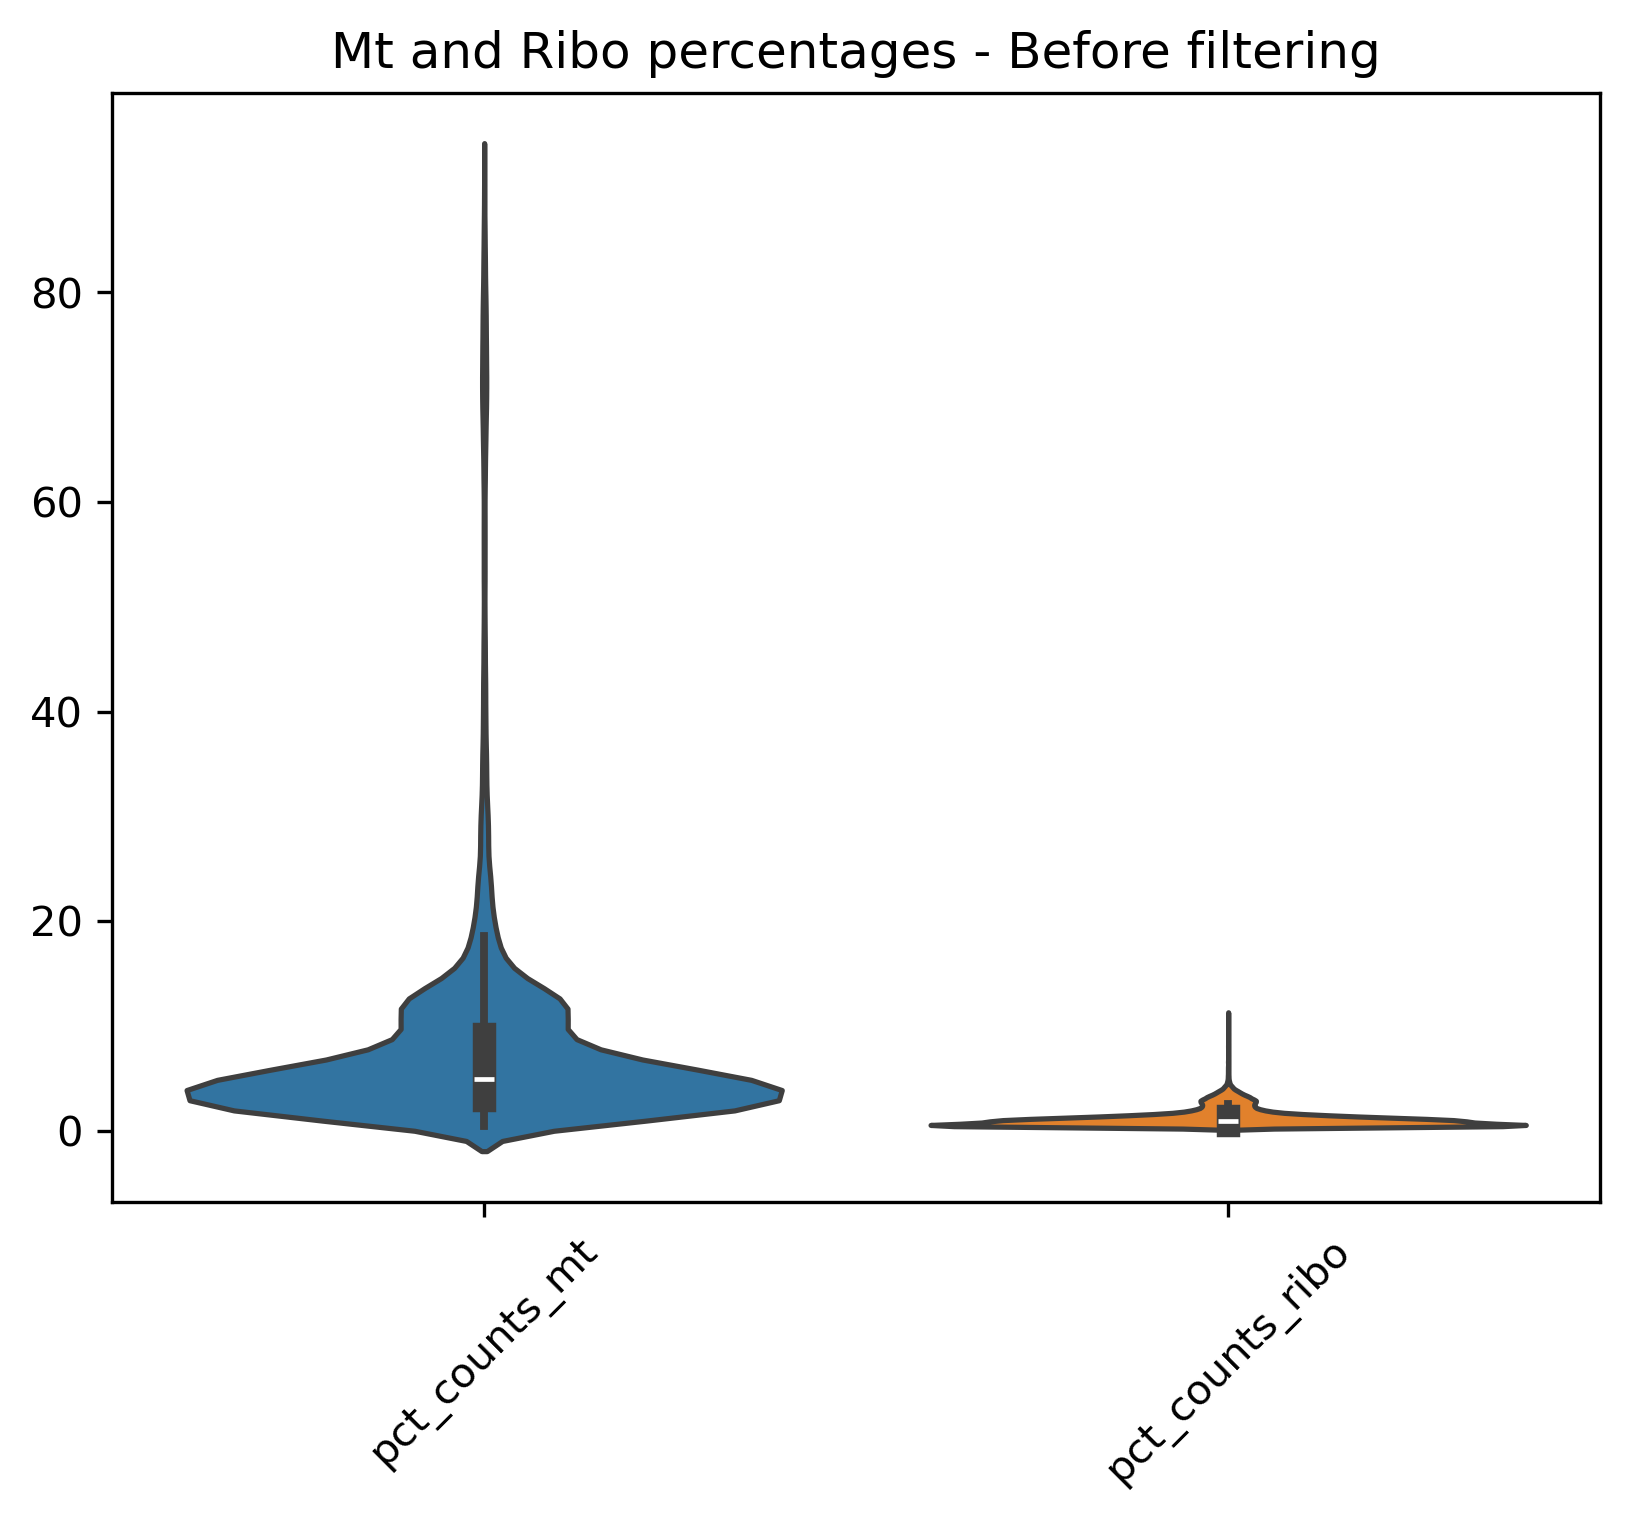

In [17]:
variables = ['pct_counts_mt', 'pct_counts_ribo']

sb.violinplot(data=raw_adata.obs[variables])
plt.xticks(rotation=45)
plt.title(f'Mt and Ribo percentages - Before filtering')

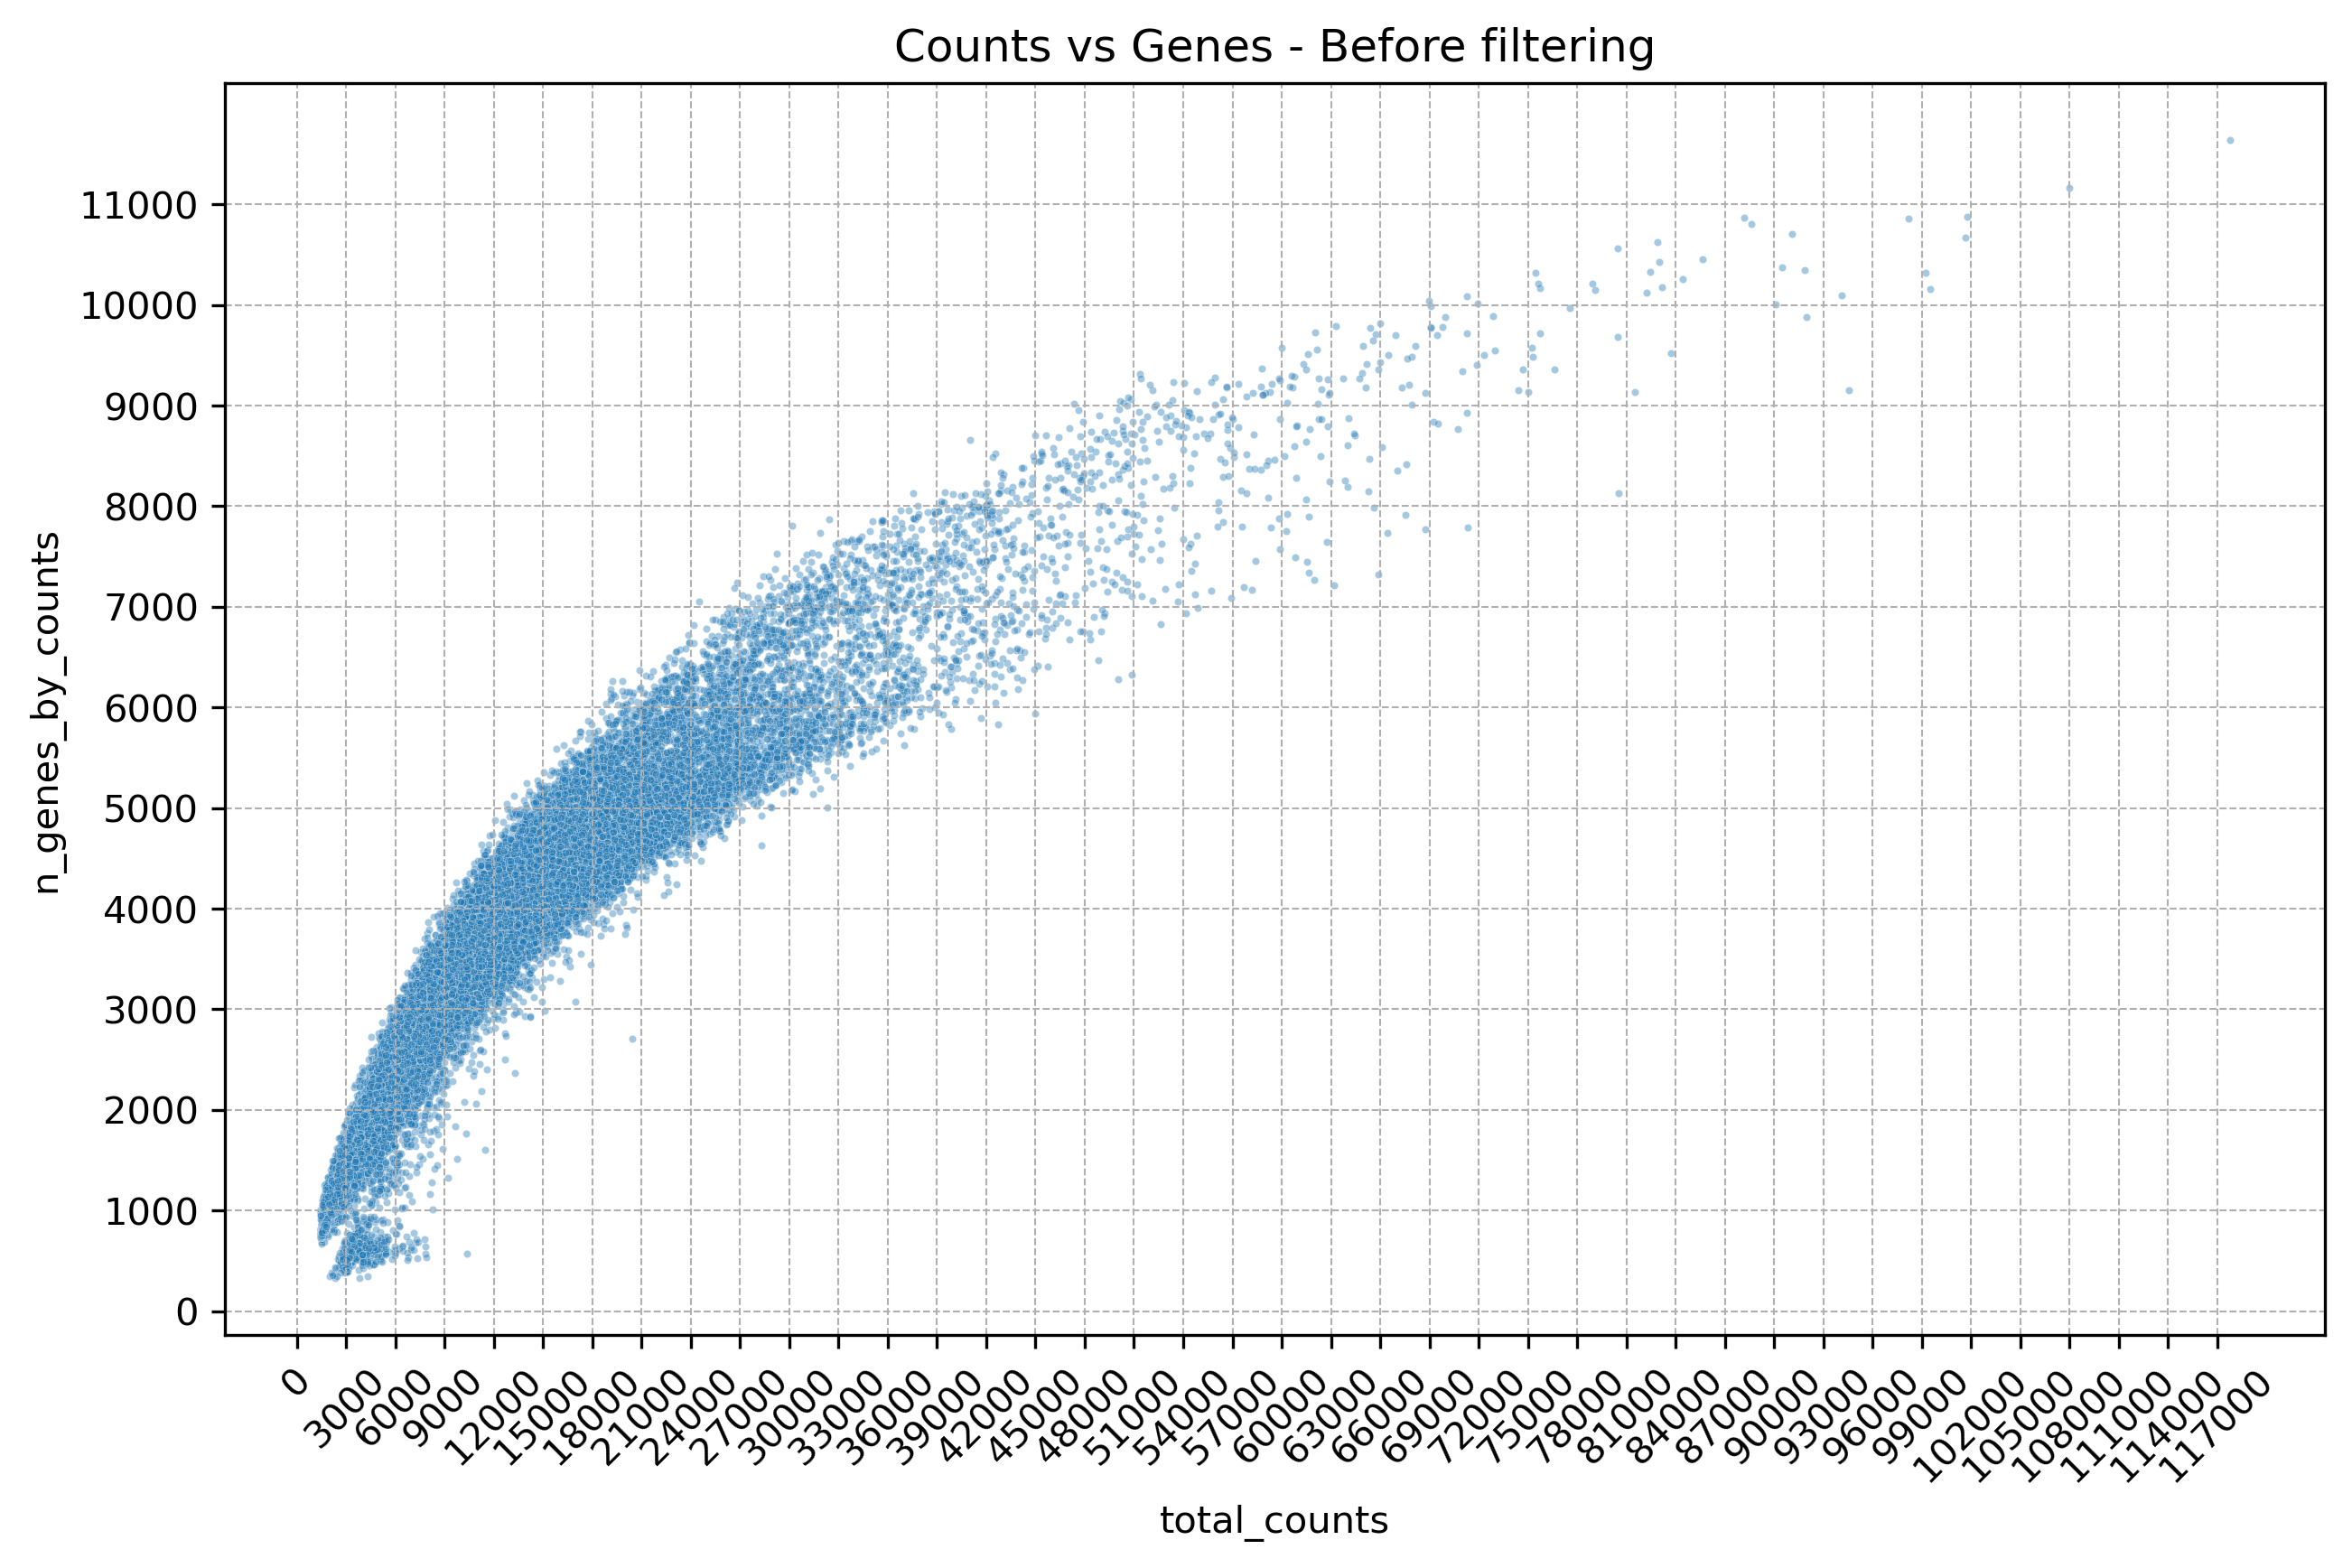

In [18]:
plt.figure(figsize=(10, 6))
sb.scatterplot(data=raw_adata.obs, x='total_counts', y='n_genes_by_counts' , alpha = 0.4, s=4)
plt.xticks(range(0, int(max(raw_adata.obs['total_counts'])) + 1, 3000),rotation=45, fontsize = 10)
plt.yticks(range(0, int(max(raw_adata.obs['n_genes_by_counts'])) + 1, 1000),fontsize = 10)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.title(f'Counts vs Genes - Before filtering')
plt.show()

### Filtering based on QC metrics

In [19]:
filtered_object = raw_adata
filtered_object

AnnData object with n_obs × n_vars = 41918 × 32285
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'ident', 'Sample_given', 'Sample-ID', 'Mouse-ID', 'Sex', 'Group', 'Nuclei Purification Method after Hashing', 'assigned_hashtag', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'X_name'
    layers: 'logcounts'

# Doublet and Negatives Check

In [20]:
doublets = filtered_object[filtered_object.obs['HTO_classification.global'] == 'Doublet'].copy()
doublets

AnnData object with n_obs × n_vars = 10847 × 32285
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'ident', 'Sample_given', 'Sample-ID', 'Mouse-ID', 'Sex', 'Group', 'Nuclei Purification Method after Hashing', 'assigned_hashtag', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'X_name'
    layers: 'logcounts'

In [21]:
negatives = filtered_object[filtered_object.obs['HTO_classification.global'] == 'Negative'].copy()
negatives

AnnData object with n_obs × n_vars = 17073 × 32285
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'ident', 'Sample_given', 'Sample-ID', 'Mouse-ID', 'Sex', 'Group', 'Nuclei Purification Method after Hashing', 'assigned_hashtag', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'X_name'
    layers: 'logcounts'

# Plotting

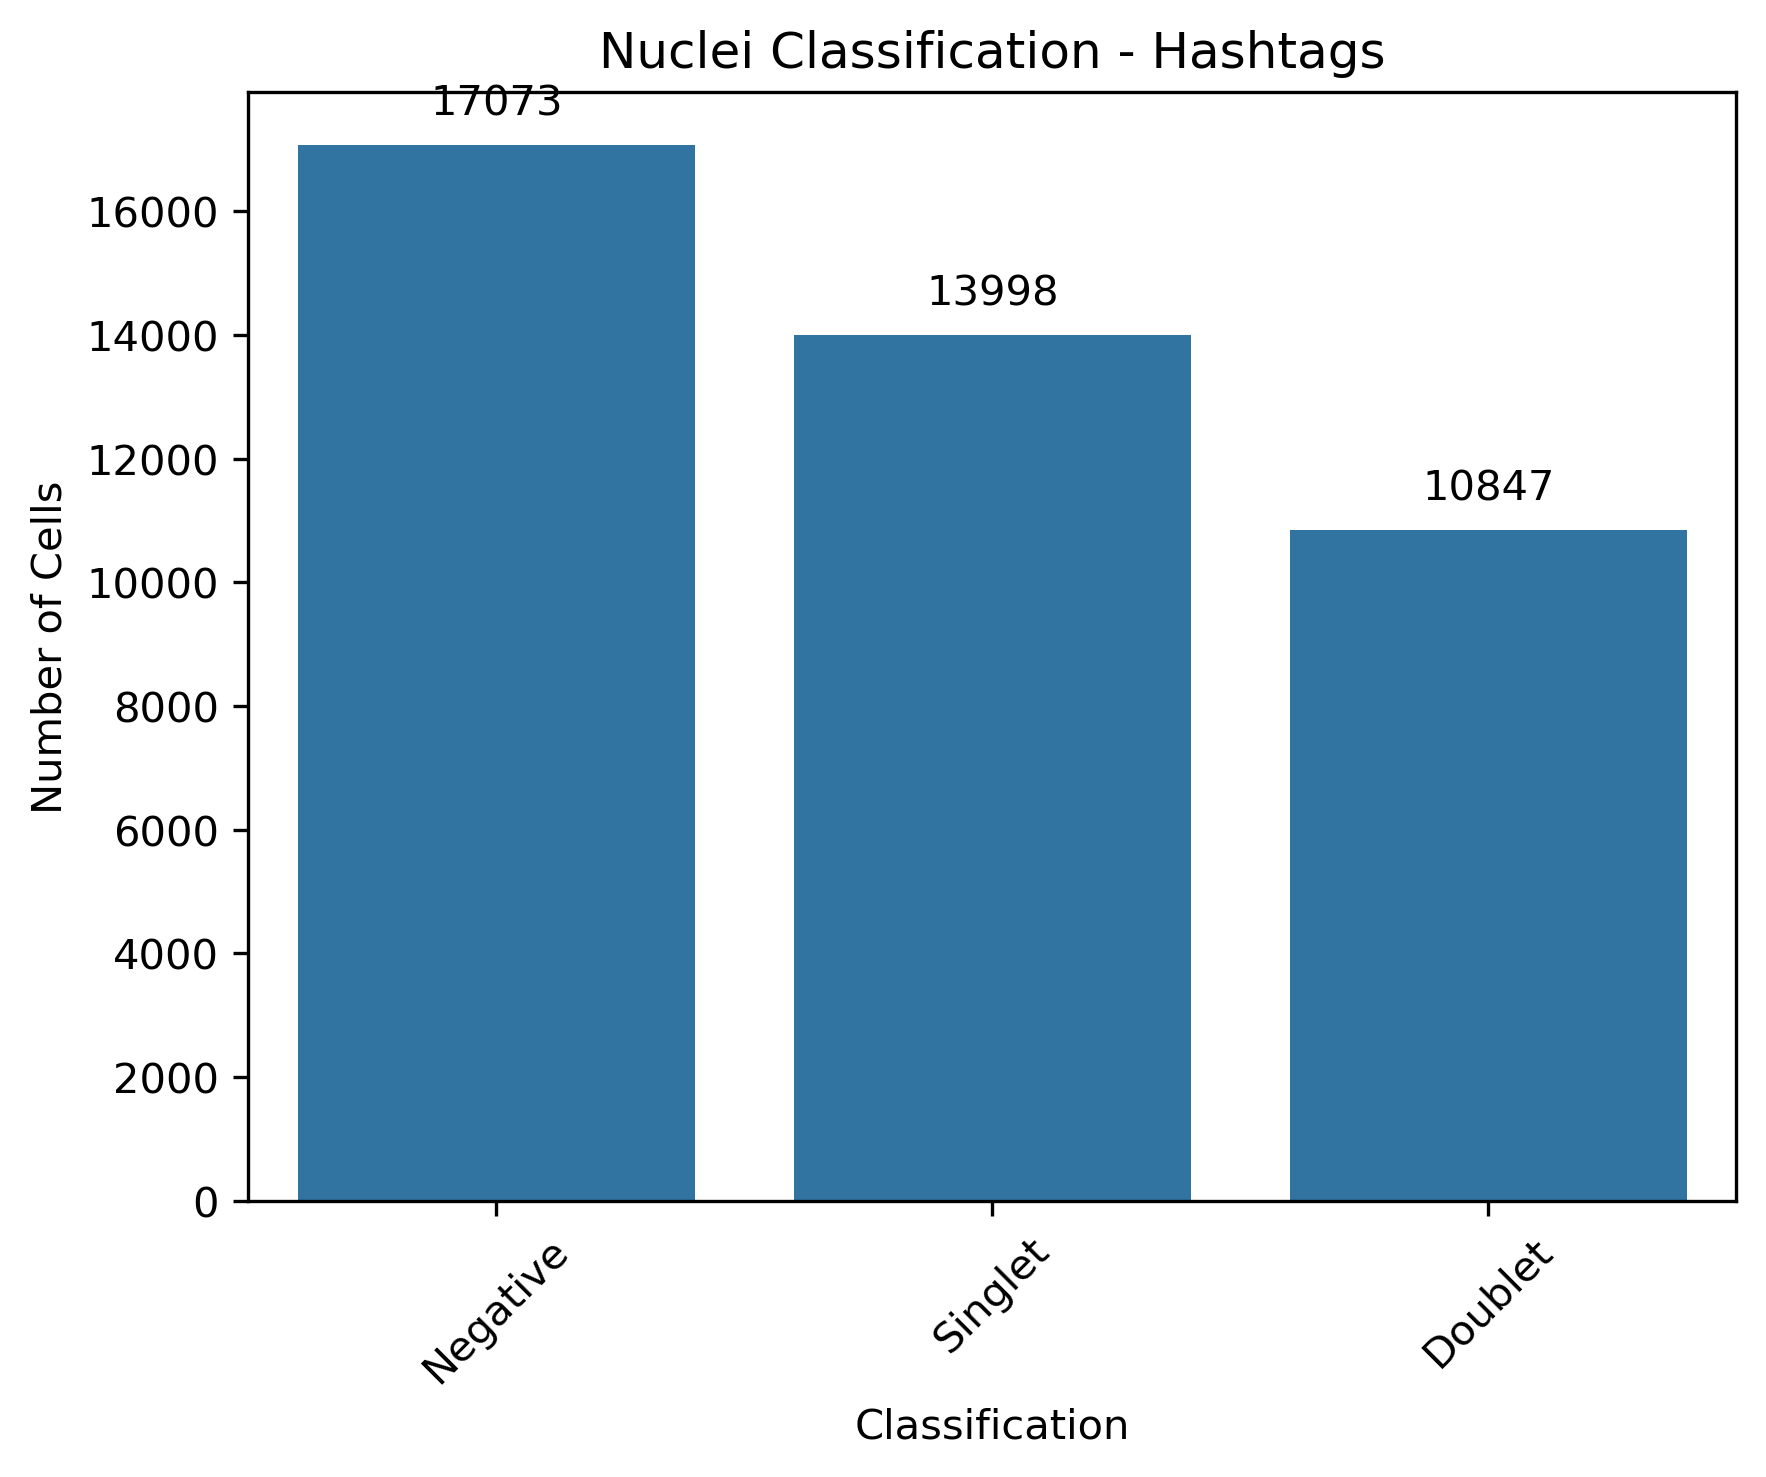

In [22]:
ax = sb.countplot(data=filtered_object.obs, x='HTO_classification.global', order=filtered_object.obs['HTO_classification.global'].value_counts().index)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=10, color='black', 
                xytext=(0, 10), textcoords='offset points')

plt.title("Nuclei Classification - Hashtags")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.xlabel("Classification")
plt.ylabel("Number of Cells")
plt.show()

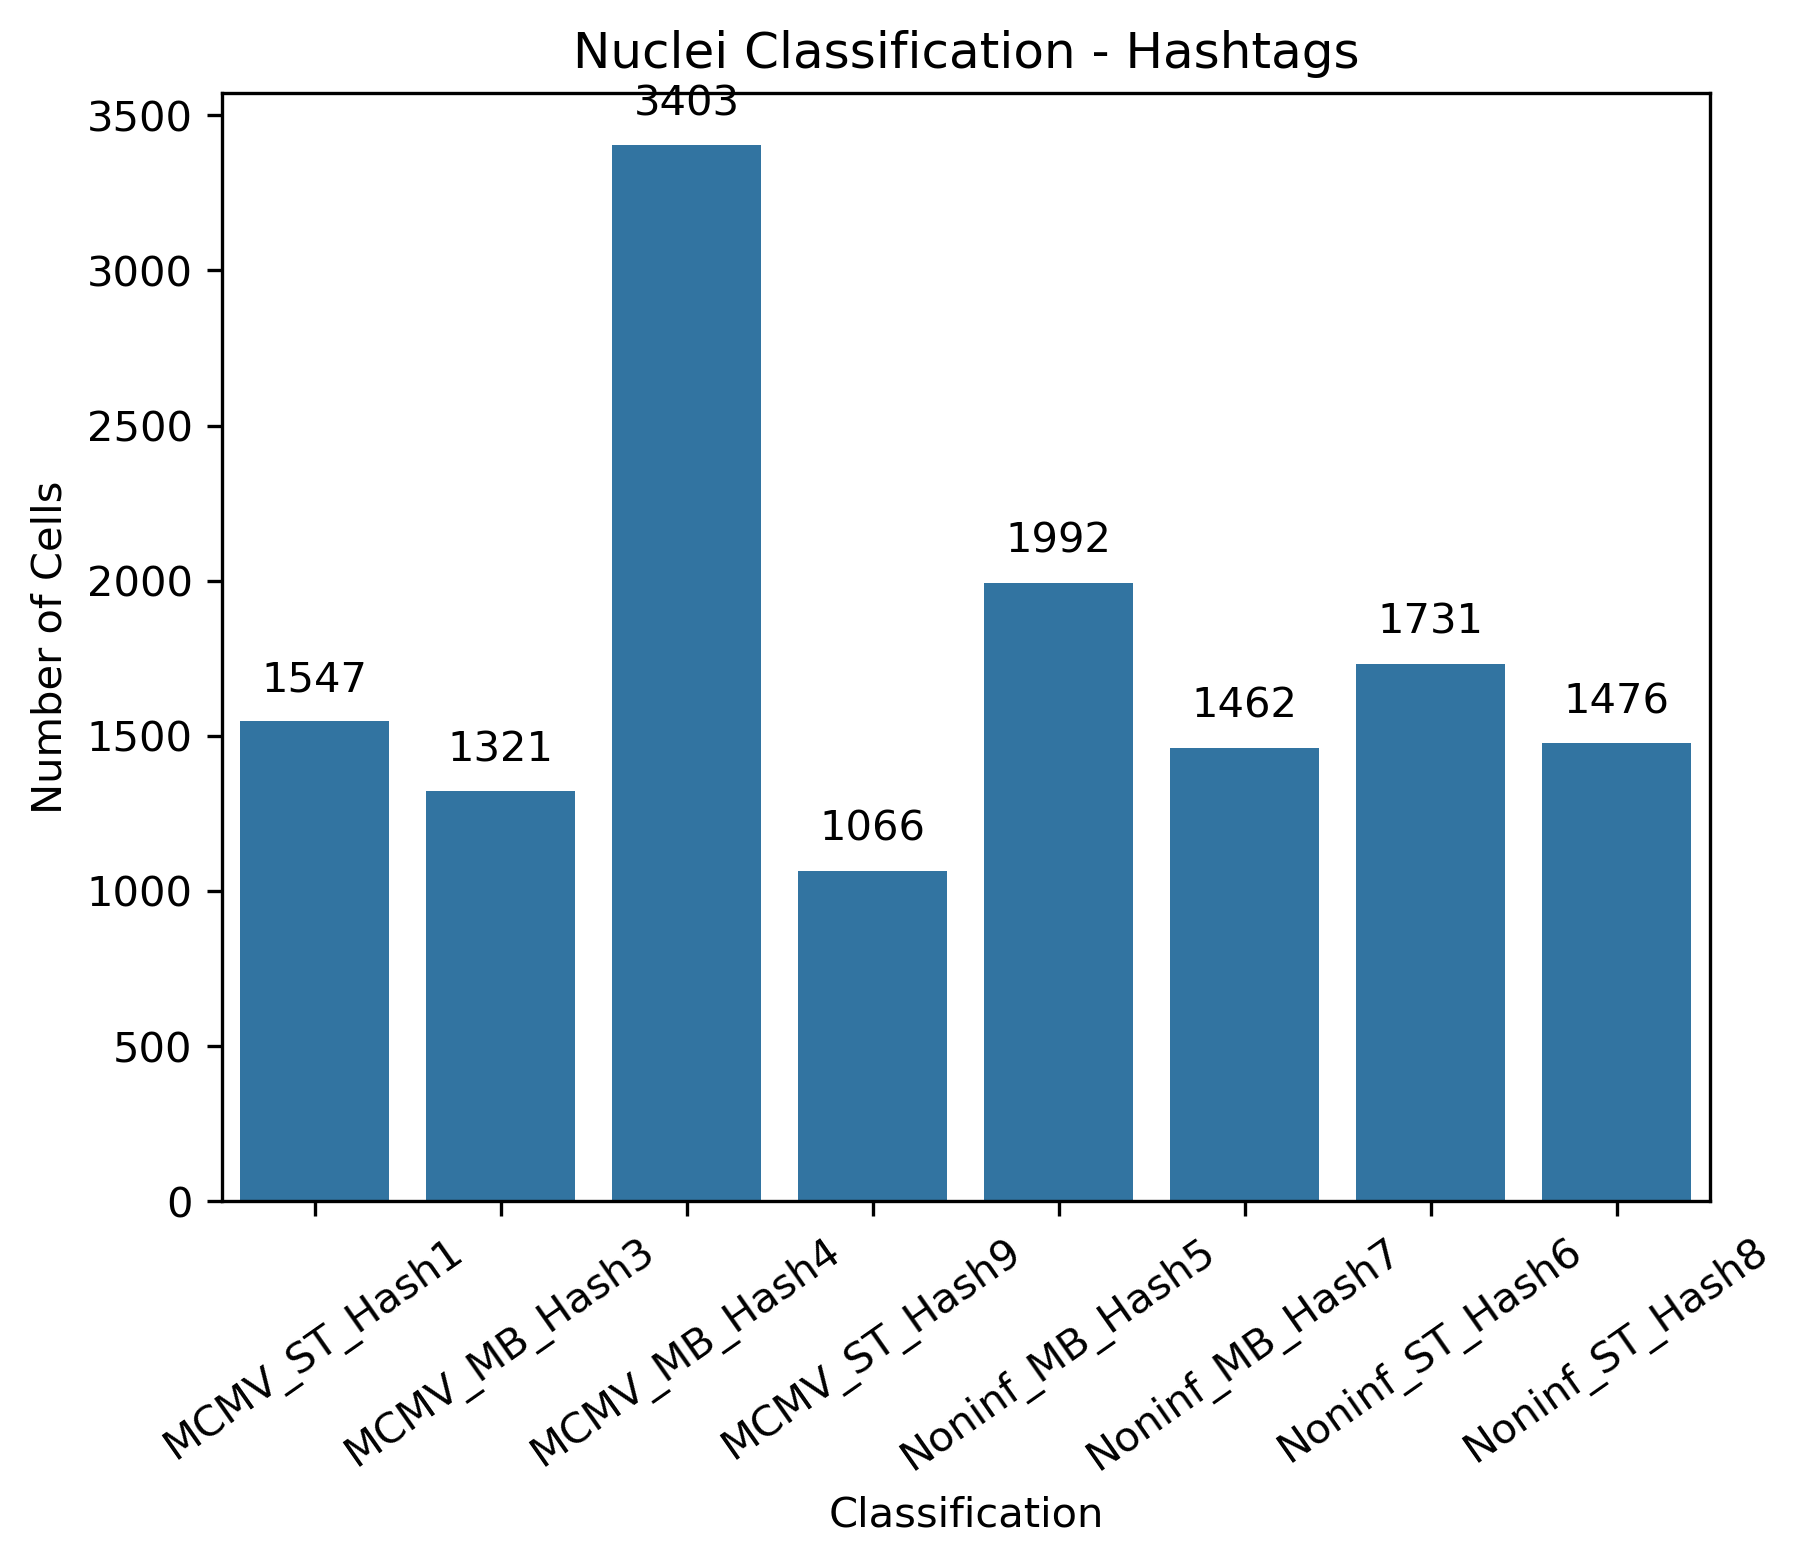

In [23]:
without_doublets = filtered_object[~filtered_object.obs['HTO_classification.global'].isin(['Doublet', 'Negative'])]

ax = sb.countplot(data=without_doublets.obs, x='assigned_hashtag', order= ["MCMV_ST_Hash1","MCMV_MB_Hash3","MCMV_MB_Hash4","MCMV_ST_Hash9","Noninf_MB_Hash5","Noninf_MB_Hash7","Noninf_ST_Hash6","Noninf_ST_Hash8"])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=10, color='black', 
                xytext=(0, 10), textcoords='offset points')

plt.title("Nuclei Classification - Hashtags")
plt.xticks(rotation=35) 
plt.xlabel("Classification")
plt.ylabel("Number of Cells")
plt.show()

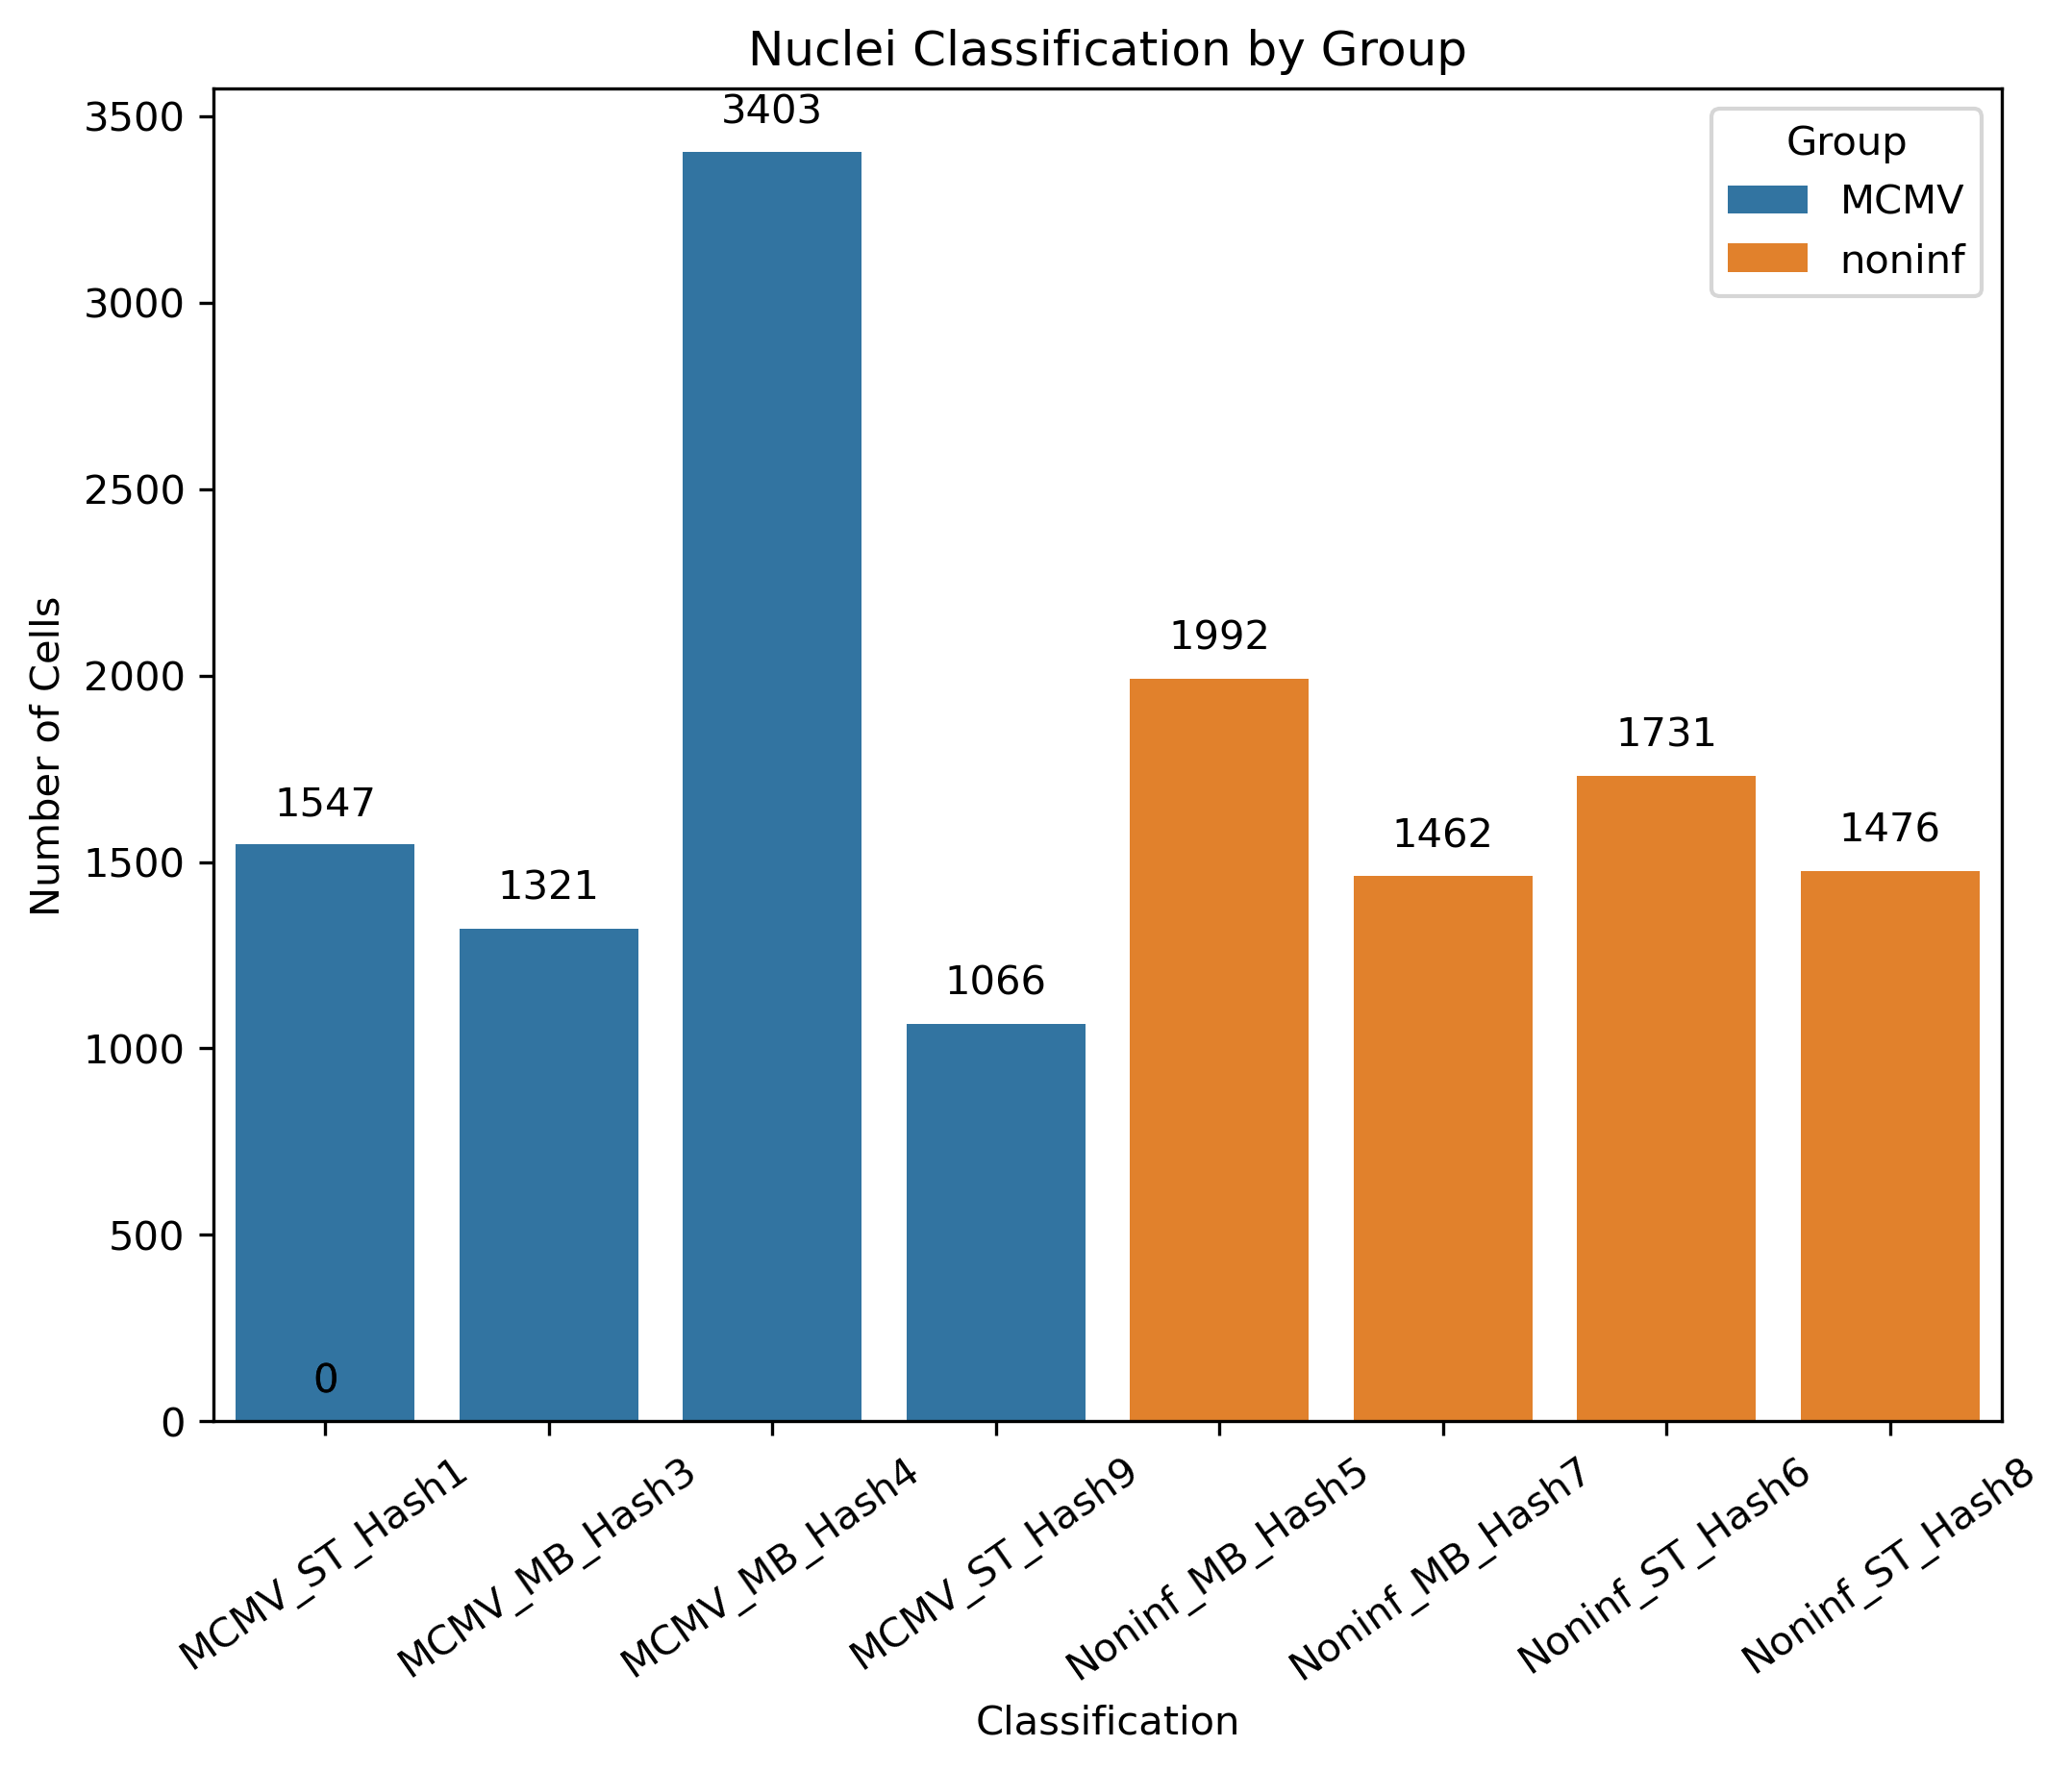

In [24]:
plt.figure(figsize=(8, 6))
ax = sb.countplot(data=without_doublets.obs, x='assigned_hashtag', hue='Group',order= ["MCMV_ST_Hash1","MCMV_MB_Hash3","MCMV_MB_Hash4","MCMV_ST_Hash9","Noninf_MB_Hash5","Noninf_MB_Hash7","Noninf_ST_Hash6","Noninf_ST_Hash8"])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=10, color='black', 
                xytext=(0, 10), textcoords='offset points')
plt.title("Nuclei Classification by Group")
plt.xlabel("Classification")
plt.ylabel("Number of Cells")
plt.xticks(rotation=35)
plt.show()

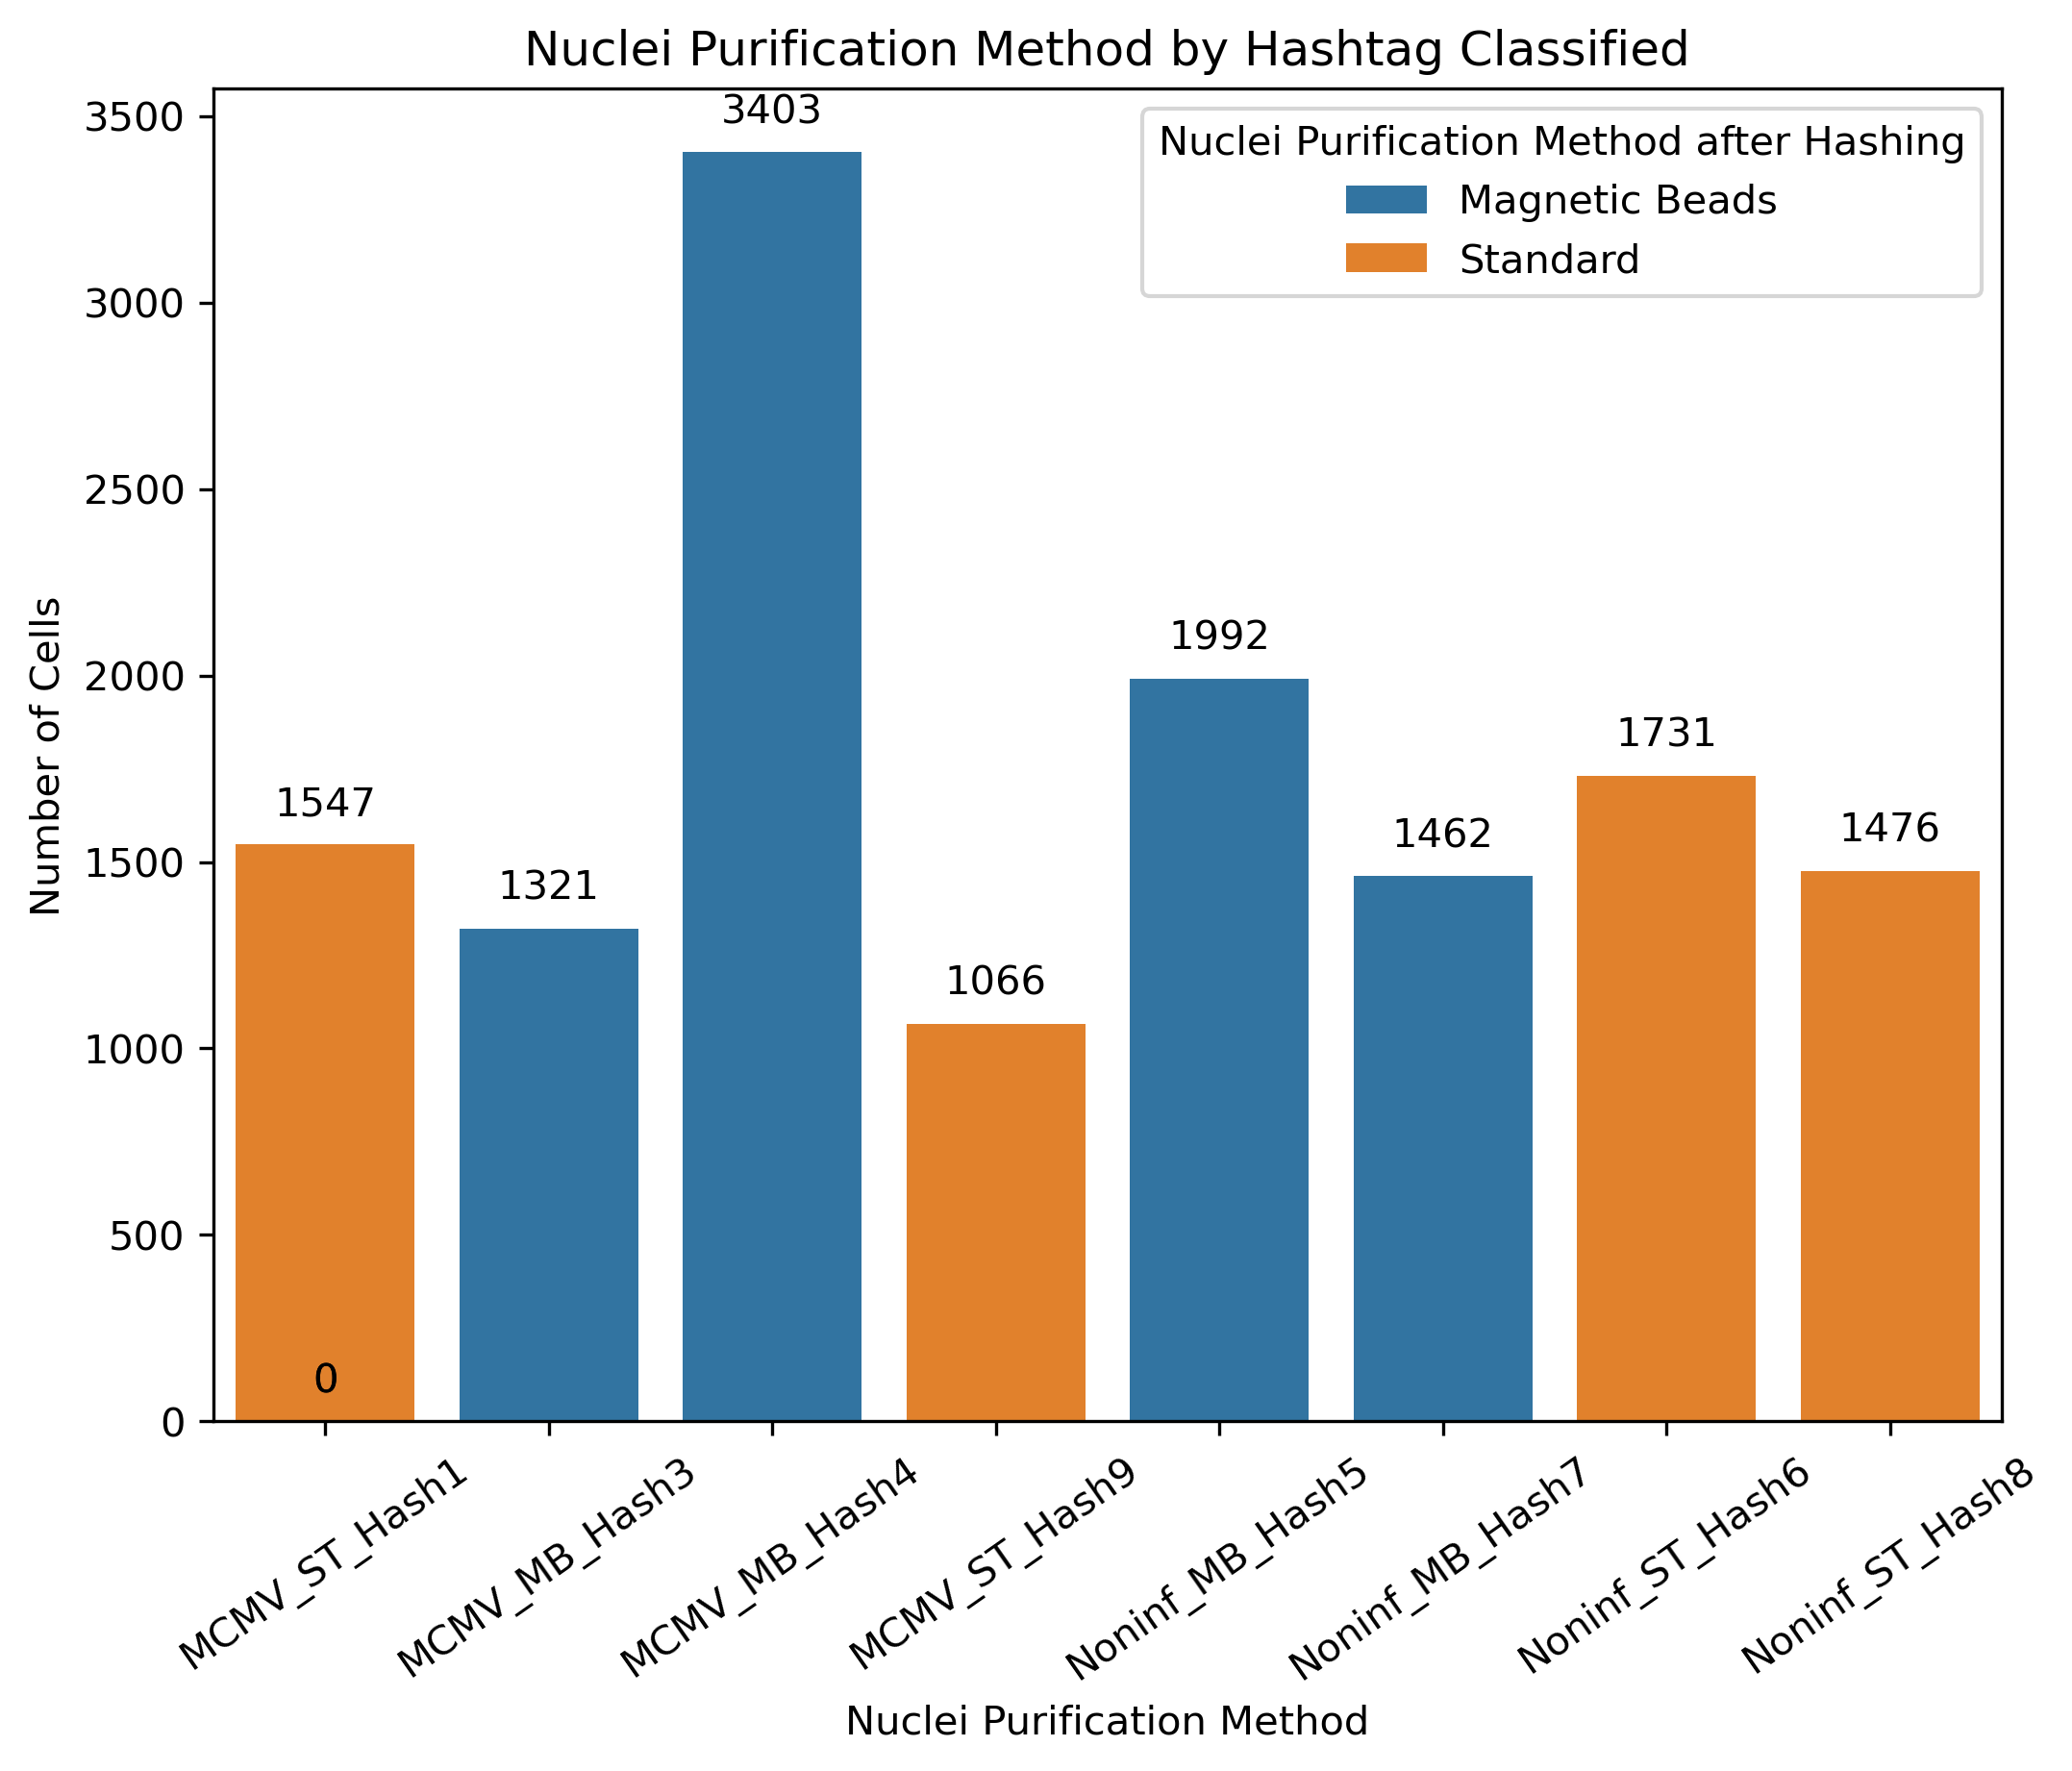

In [25]:
plt.figure(figsize=(8, 6))
ax = sb.countplot(data=without_doublets.obs, hue='Nuclei Purification Method after Hashing',  x='assigned_hashtag',order= ["MCMV_ST_Hash1","MCMV_MB_Hash3","MCMV_MB_Hash4","MCMV_ST_Hash9","Noninf_MB_Hash5","Noninf_MB_Hash7","Noninf_ST_Hash6","Noninf_ST_Hash8"])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=10, color='black', 
                xytext=(0, 10), textcoords='offset points')
plt.title("Nuclei Purification Method by Hashtag Classified")
plt.xlabel("Nuclei Purification Method")
plt.ylabel("Number of Cells")
plt.xticks(rotation=35)
plt.show()

## Data Export

In [26]:
filtered_object.obs.dtypes

orig.ident                                  category
nCount_RNA                                   float64
nFeature_RNA                                   int32
nCount_HTO                                   float64
nFeature_HTO                                   int32
HTO_maxID                                   category
HTO_secondID                                category
HTO_margin                                   float64
HTO_classification                            object
HTO_classification.global                   category
hash.ID                                     category
ident                                       category
Sample_given                                  object
Sample-ID                                    float64
Mouse-ID                                      object
Sex                                           object
Group                                         object
Nuclei Purification Method after Hashing      object
assigned_hashtag                              

In [27]:
filtered_object.write_h5ad(f'./data/demultiplexed_HTODemux_raw_{timestamp}.h5ad')